# 01 — FER-2013 Dataset Exploration

**Project:** IT22638168 — MaternaLink FER track
**Pipeline position:** step 1 of 8 · see `../README.md`

## Purpose

- Load FER-2013 and report total sample count per split.
- Plot the class distribution across all 7 emotions. FER-2013 is known to be imbalanced — quantify it.
- Identify corrupt, duplicate, and non-face samples.
- Inspect image quality, resolution, and grayscale consistency.
- Record findings that affect the 7->3 mood mapping (MOOD_STATE_SPEC.md SB2).

## Before running

Read `../../../docs/system/MOOD_STATE_SPEC.md` — it defines the label space this model targets.

> **Note:** Do NOT decide the 7->3 mood mapping here. This notebook produces the evidence; the mapping decision follows the AffectNet valence/arousal procedure in MOOD_STATE_SPEC.md SB2.

## Status

Not yet run.


> **Scope of this notebook.** This notebook only *characterises* the raw FER-2013 data as
> delivered. It does **not** physically create any train/val/test split on disk, and it does
> **not** make any modelling decision — in particular it does not use PrivateTest for anything
> other than being counted and described like every other file. The PrivateTest set stays an
> untouched holdout; nothing here reads its labels for a modelling purpose. It also does not
> propose, encode, or imply any 7→3 mood-label mapping.


## Environment setup

Resolves whether we are on Colab or local, mounts Drive + extracts the zip on Colab (auto-detecting
whatever top-level folder structure is inside it), and resolves `DATA_ROOT`, `OUT_DIR`, `PLOT_DIR`
once so every later cell reuses them.


In [2]:
import os
import zipfile

# --- Colab detection -------------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("IN_COLAB:", IN_COLAB)

# --- Mount Drive + extract zip (Colab only) ---------------------------------
DRIVE_ZIP = "/content/drive/MyDrive/Datsets/fer2013.zip"  # sic: "Datsets" is the real folder name
EXTRACT_DIR = "/content/fer_data"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.isdir(EXTRACT_DIR) or not os.listdir(EXTRACT_DIR):
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        print("Extracting", DRIVE_ZIP, "->", EXTRACT_DIR)
        with zipfile.ZipFile(DRIVE_ZIP, "r") as zf:
            zf.extractall(EXTRACT_DIR)
    else:
        print("Extraction dir already populated, skipping extract:", EXTRACT_DIR)

    SEARCH_ROOT = EXTRACT_DIR
else:
    # Local fallback for reruns outside Colab.
    SEARCH_ROOT = "../data/raw"

print("SEARCH_ROOT:", SEARCH_ROOT)

# --- Auto-detect DATA_ROOT: the directory that directly contains both --------
# --- "train" and "test", searching up to 3 levels deep below SEARCH_ROOT. ---

def find_data_root(search_root, max_depth=3):
    if not os.path.isdir(search_root):
        raise FileNotFoundError(f"SEARCH_ROOT does not exist: {search_root}")

    candidates = [(search_root, 0)]
    visited = []
    while candidates:
        current, depth = candidates.pop(0)
        try:
            entries = os.listdir(current)
        except OSError:
            continue
        visited.append(current)
        entries_lower = {e.lower(): e for e in entries}
        if "train" in entries_lower and "test" in entries_lower:
            train_path = os.path.join(current, entries_lower["train"])
            test_path = os.path.join(current, entries_lower["test"])
            if os.path.isdir(train_path) and os.path.isdir(test_path):
                return current
        if depth < max_depth:
            for e in entries:
                sub = os.path.join(current, e)
                if os.path.isdir(sub):
                    candidates.append((sub, depth + 1))
    raise FileNotFoundError(
        "Could not find a directory containing both 'train' and 'test' within "
        f"{max_depth} levels of '{search_root}'. Directories examined: {visited}"
    )

DATA_ROOT = find_data_root(SEARCH_ROOT)
print("Resolved DATA_ROOT:", DATA_ROOT)

# --- Output directories: the repo does not exist on Colab --------------------
if IN_COLAB:
    OUT_DIR = "/content/maternalink_fer/outputs"
    PLOT_DIR = "/content/maternalink_fer/plots"
else:
    OUT_DIR = "../outputs"
    PLOT_DIR = "../plots"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)
print("PLOT_DIR:", PLOT_DIR)


Mounted at /content/drive
Extracting /content/drive/MyDrive/Datsets/fer2013.zip -> /content/fer_data
SEARCH_ROOT: /content/fer_data
Resolved DATA_ROOT: /content/fer_data
OUT_DIR: /content/maternalink_fer/outputs
PLOT_DIR: /content/maternalink_fer/plots


## Run metadata

Every training/evaluation notebook records its own run (Gate 1A resolution: no separate
experiment-tracking infrastructure, the notebook is responsible for itself — satisfies NFR-12).
This cell must run **after** environment setup so it can capture the resolved `DATA_ROOT` and
`environment` values.


In [3]:
"""Run metadata — every training/evaluation notebook records its own run.

This is the project's experiment tracking (Gate 1A resolution): no separate
infrastructure, the notebook is responsible. Satisfies NFR-12.
"""
import json, os, time, random, sys, platform, importlib.metadata
import numpy as np

def _pkg_version(name, module=None):
    """Best-effort package version lookup; never raises."""
    try:
        return importlib.metadata.version(name)
    except Exception:
        pass
    try:
        mod = module or __import__(name)
        return getattr(mod, "__version__", "unknown")
    except Exception:
        return "unknown"

PACKAGE_VERSIONS = {
    "python":     sys.version.split()[0],
    "numpy":      _pkg_version("numpy"),
    "pandas":     _pkg_version("pandas"),
    "Pillow":     _pkg_version("Pillow", module=__import__("PIL")),
    "matplotlib": _pkg_version("matplotlib"),
}

RUN = {
    "run_id":            time.strftime("run_%Y%m%d_%H%M%S"),
    "timestamp":         time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook":           "01_dataset_exploration",
    "dataset":            "FER-2013",
    "dataset_path":       DATA_ROOT,
    "dataset_version":    None,   # set once data/processed/ is written
    "model_version":      None,   # set when a model is saved
    "environment":        "colab" if IN_COLAB else "local",
    "package_versions":   PACKAGE_VERSIONS,
    "hyperparameters":    {},     # lr, batch_size, epochs, augmentation...
    "random_seed":        42,
    "metrics":            {},     # accuracy, macro_f1, per_class... (populated below at the end)
    "notes":              "",
}

random.seed(RUN["random_seed"])
np.random.seed(RUN["random_seed"])

def save_run(run=RUN, outdir=None):
    """Write the run record. Call at the END of the notebook."""
    if outdir is None:
        outdir = OUT_DIR
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, run["run_id"] + ".json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(run, f, indent=2)
    print("saved:", path)
    return path

print(json.dumps(RUN, indent=2))
RUN["run_id"]


{
  "run_id": "run_20260818_220610",
  "timestamp": "2026-08-18 22:06:10",
  "notebook": "01_dataset_exploration",
  "dataset": "FER-2013",
  "dataset_path": "/content/fer_data",
  "dataset_version": null,
  "model_version": null,
  "environment": "colab",
  "package_versions": {
    "python": "3.12.13",
    "numpy": "2.0.2",
    "pandas": "2.2.3",
    "Pillow": "11.3.0",
    "matplotlib": "3.10.0"
  },
  "hyperparameters": {},
  "random_seed": 42,
  "metrics": {},
  "notes": ""
}


'run_20260818_220610'

---

## Work starts here

## 0. Single-pass load: every image, once

To keep this notebook fast, every file under `DATA_ROOT` is visited exactly once here. For each
file we record: its raw bytes' MD5, on-disk size, PIL `mode`, original `(width, height)`, whether
it is corrupt/unreadable, and — if readable — its pixel data as a grayscale `uint8` array. All
later analyses (dimensions, channels, corruption, hashing/duplicates, pixel stats, sample grids,
quality anomalies) reuse these same in-memory arrays; none of them re-walk the filesystem.

A progress line is printed every ~5000 files.


In [4]:
import re
import io
import hashlib
import time as _time
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLASS_NAMES_TRAIN = sorted(
    d for d in os.listdir(os.path.join(DATA_ROOT, "train"))
    if os.path.isdir(os.path.join(DATA_ROOT, "train", d))
)
CLASS_NAMES_TEST = sorted(
    d for d in os.listdir(os.path.join(DATA_ROOT, "test"))
    if os.path.isdir(os.path.join(DATA_ROOT, "test", d))
)
assert set(CLASS_NAMES_TRAIN) == set(CLASS_NAMES_TEST), (
    f"train/test class sets differ: {set(CLASS_NAMES_TRAIN)} vs {set(CLASS_NAMES_TEST)}"
)
CLASS_NAMES = CLASS_NAMES_TRAIN
print("Class directories (sorted):", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

PREFIX_PATTERN = re.compile(r"^(Training_|PublicTest_|PrivateTest_)")

def extract_prefix(filename):
    m = PREFIX_PATTERN.match(filename)
    return m.group(1) if m else "other"

TARGET_H, TARGET_W = 48, 48  # FER-2013's documented image size; used only as the array
                              # shape for pixel-stat/hashing purposes. True per-file
                              # dimensions are recorded separately in `widths`/`heights`
                              # regardless of this constant, so a mismatch is still visible.

# --- pass 1: enumerate every file (cheap, no image decoding) ----------------
file_records = []  # (path, split, cls, filename)
for split in ("train", "test"):
    split_dir = os.path.join(DATA_ROOT, split)
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            if os.path.isfile(fpath):
                file_records.append((fpath, split, cls, fname))

N = len(file_records)
print(f"Total files found: {N}")

# --- pass 2: decode every file once, fill parallel arrays -------------------
images       = np.zeros((N, TARGET_H, TARGET_W), dtype=np.uint8)
paths        = [None] * N
splits       = np.empty(N, dtype=object)
classes      = np.empty(N, dtype=object)
prefixes     = np.empty(N, dtype=object)
widths       = np.full(N, -1, dtype=np.int64)
heights      = np.full(N, -1, dtype=np.int64)
modes        = np.empty(N, dtype=object)
filesizes    = np.zeros(N, dtype=np.int64)
md5_hashes   = np.empty(N, dtype=object)
is_corrupt   = np.zeros(N, dtype=bool)
resized_flag = np.zeros(N, dtype=bool)  # True if original size != (TARGET_W, TARGET_H)

t0 = _time.time()
for i, (fpath, split, cls, fname) in enumerate(file_records):
    paths[i] = fpath
    splits[i] = split
    classes[i] = cls
    prefixes[i] = extract_prefix(fname)

    try:
        with open(fpath, "rb") as f:
            raw = f.read()
    except OSError:
        is_corrupt[i] = True
        md5_hashes[i] = None
        if (i + 1) % 5000 == 0 or (i + 1) == N:
            print(f"  ...{i + 1}/{N} files processed ({_time.time() - t0:.1f}s elapsed)")
        continue

    filesizes[i] = len(raw)
    md5_hashes[i] = hashlib.md5(raw).hexdigest()

    corrupt = False
    if len(raw) == 0:
        corrupt = True
    else:
        try:
            with Image.open(io.BytesIO(raw)) as im_verify:
                im_verify.verify()
        except Exception:
            corrupt = True

    if not corrupt:
        try:
            with Image.open(io.BytesIO(raw)) as im:
                modes[i] = im.mode
                w, h = im.size
                widths[i] = w
                heights[i] = h
                gray = im.convert("L")
                arr = np.array(gray, dtype=np.uint8)
                if arr.shape != (TARGET_H, TARGET_W):
                    resized_flag[i] = True
                    arr = np.array(
                        gray.resize((TARGET_W, TARGET_H), Image.BILINEAR), dtype=np.uint8
                    )
                images[i] = arr
        except Exception:
            corrupt = True

    is_corrupt[i] = corrupt

    if (i + 1) % 5000 == 0 or (i + 1) == N:
        print(f"  ...{i + 1}/{N} files processed ({_time.time() - t0:.1f}s elapsed)")

print(f"Done. Loaded {N} files in {_time.time() - t0:.1f}s.")
print(f"Corrupt/unreadable: {int(is_corrupt.sum())}")

paths = np.array(paths, dtype=object)

TRAIN_MASK_ALL = (splits == "train")
TEST_SPLIT_MASK_ALL = (splits == "test")


Class directories (sorted): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7
Total files found: 35887
  ...5000/35887 files processed (1.7s elapsed)
  ...10000/35887 files processed (2.9s elapsed)
  ...15000/35887 files processed (4.0s elapsed)
  ...20000/35887 files processed (5.2s elapsed)
  ...25000/35887 files processed (6.3s elapsed)
  ...30000/35887 files processed (7.3s elapsed)
  ...35000/35887 files processed (8.4s elapsed)
  ...35887/35887 files processed (8.6s elapsed)
Done. Loaded 35887 files in 8.6s.
Corrupt/unreadable: 0


## 1. Location & format confirmation

Confirm the resolved dataset location, the directory tree (splits x classes), and the file
extension census, and confirm this is a standard `ImageFolder`-style layout
(`DATA_ROOT/<split>/<class>/<file>`).


In [5]:
print("Resolved DATA_ROOT:", DATA_ROOT)
print()
print("Directory tree (split -> class -> file count):")
tree_rows = []
for split in ("train", "test"):
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        n_files = len(os.listdir(cls_dir)) if os.path.isdir(cls_dir) else 0
        tree_rows.append({"split": split, "class": cls, "file_count": n_files})
tree_df = pd.DataFrame(tree_rows)
print(tree_df.to_string(index=False))

print()
print("File extension census:")
ext_counts = pd.Series([os.path.splitext(p)[1].lower() for p in paths]).value_counts()
print(ext_counts.to_string())

is_imagefolder = tree_df["file_count"].sum() == N
print()
print("ImageFolder layout confirmed (DATA_ROOT/<split>/<class>/<file>):", is_imagefolder)


Resolved DATA_ROOT: /content/fer_data

Directory tree (split -> class -> file count):
split    class  file_count
train    angry        3995
train  disgust         436
train     fear        4097
train    happy        7215
train  neutral        4965
train      sad        4830
train surprise        3171
 test    angry         958
 test  disgust         111
 test     fear        1024
 test    happy        1774
 test  neutral        1233
 test      sad        1247
 test surprise         831

File extension census:
.jpg    35887

ImageFolder layout confirmed (DATA_ROOT/<split>/<class>/<file>): True


## 2. Class distribution

Counts and percentages for `train` and `test`, reported **separately**, plus the max:min
imbalance ratio for each split and the overall totals.


TRAIN class distribution:
   class  count  percent
   angry   3995    13.92
 disgust    436     1.52
    fear   4097    14.27
   happy   7215    25.13
 neutral   4965    17.29
     sad   4830    16.82
surprise   3171    11.05
TRAIN max:min imbalance ratio: 16.55

TEST class distribution:
   class  count  percent
   angry    958    13.35
 disgust    111     1.55
    fear   1024    14.27
   happy   1774    24.71
 neutral   1233    17.18
     sad   1247    17.37
surprise    831    11.58
TEST max:min imbalance ratio: 15.98

Totals: train = 28709 | test = 7178 | overall = 35887


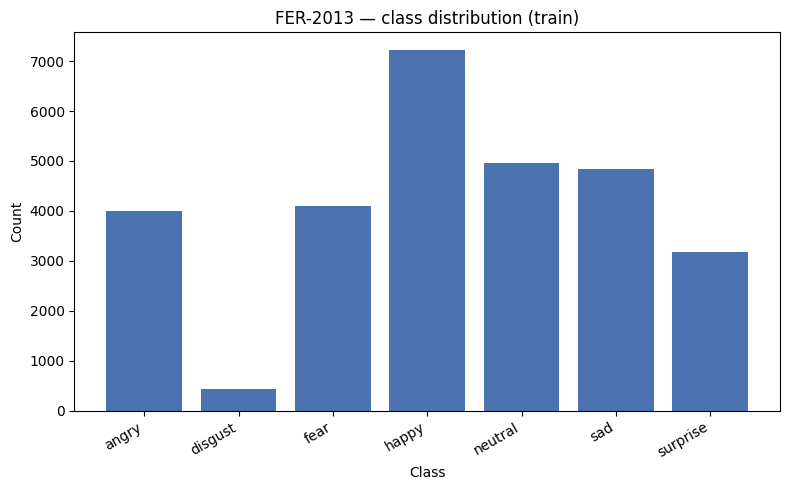

In [6]:
def class_distribution_table(mask):
    vals, counts = np.unique(classes[mask], return_counts=True)
    df = pd.DataFrame({"class": vals, "count": counts})
    df = df.set_index("class").reindex(CLASS_NAMES).fillna(0).astype({"count": int}).reset_index()
    total = df["count"].sum()
    df["percent"] = (df["count"] / total * 100).round(2) if total > 0 else 0.0
    return df

train_dist = class_distribution_table(splits == "train")
test_dist = class_distribution_table(splits == "test")

print("TRAIN class distribution:")
print(train_dist.to_string(index=False))
train_ratio = train_dist["count"].max() / max(train_dist["count"].min(), 1)
print(f"TRAIN max:min imbalance ratio: {train_ratio:.2f}")

print()
print("TEST class distribution:")
print(test_dist.to_string(index=False))
test_ratio = test_dist["count"].max() / max(test_dist["count"].min(), 1)
print(f"TEST max:min imbalance ratio: {test_ratio:.2f}")

print()
print("Totals: train =", int(train_dist["count"].sum()),
      "| test =", int(test_dist["count"].sum()),
      "| overall =", N)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(train_dist["class"], train_dist["count"], color="#4C72B0")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("FER-2013 — class distribution (train)")
for tick in ax.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "class_distribution_train.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. Prefix census — highest-priority integrity check

FER-2013 filenames carry a `Training_` / `PublicTest_` / `PrivateTest_` prefix that encodes the
*true* underlying split, independent of the `train`/`test` directory a file happens to sit in. This
cell cross-tabulates directory-split x filename-prefix and explicitly tests the three invariants
this notebook depends on for the rest of the analysis:

- `train/` contains **only** `Training_` files
- `test/` contains **only** `PublicTest_` and `PrivateTest_` files
- there are **zero** `other`-prefix files

It then defines `VAL_MASK` (`test/` + `PublicTest_`) and `TEST_MASK` (`test/` + `PrivateTest_`),
which every later analysis reuses to report train/val/test separately instead of just train/test.


split x prefix cross-tabulation:
col_0  Training_  PublicTest_  PrivateTest_  other
row_0                                             
test           0         3589          3589      0
train      28709            0             0      0

PREFIX CENSUS RESULTS:
  [PASS] train/ contains ONLY Training_ files
  [PASS] test/ contains ONLY PublicTest_ and PrivateTest_ files
  [PASS] zero other-prefix files

Prefix census: ALL CHECKS PASSED.

Logical group counts:
  TRAIN (train/ + Training_):        28709
  VAL   (test/  + PublicTest_):       3589
  TEST  (test/  + PrivateTest_):      3589

VAL (PublicTest) class distribution:
   class  count  percent
   angry    467    13.01
 disgust     56     1.56
    fear    496    13.82
   happy    895    24.94
 neutral    607    16.91
     sad    653    18.19
surprise    415    11.56

TEST (PrivateTest) class distribution:
   class  count  percent
   angry    491    13.68
 disgust     55     1.53
    fear    528    14.71
   happy    879    24.49
 neutr

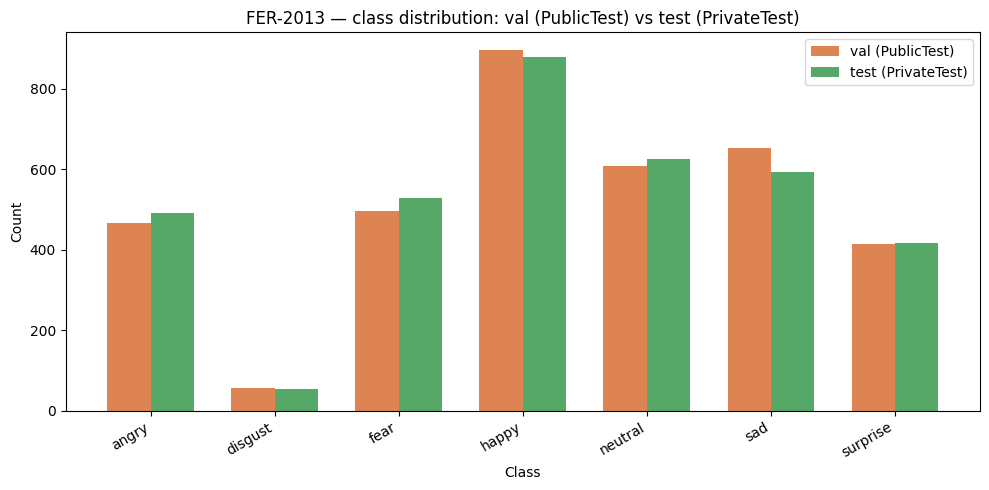

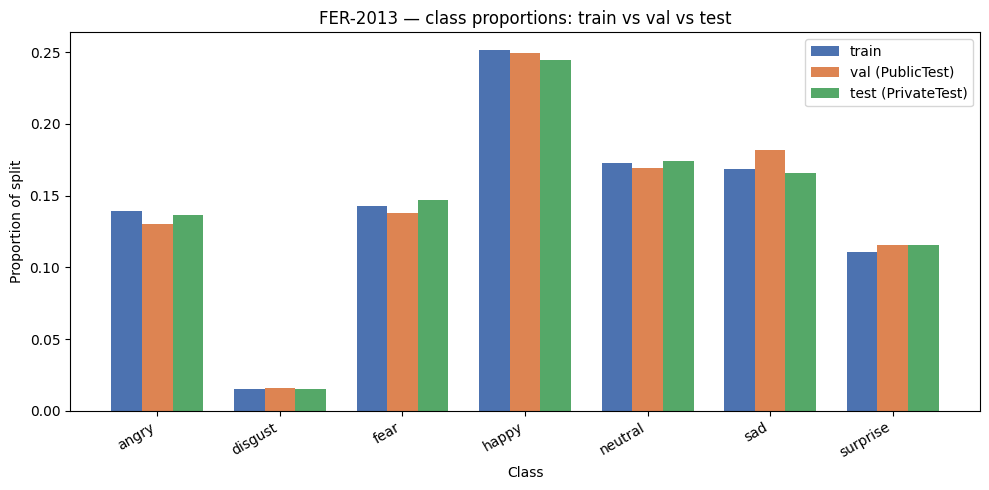

In [7]:
cross_tab = pd.crosstab(splits, prefixes)
for p in ("Training_", "PublicTest_", "PrivateTest_", "other"):
    if p not in cross_tab.columns:
        cross_tab[p] = 0
cross_tab = cross_tab[["Training_", "PublicTest_", "PrivateTest_", "other"]]
print("split x prefix cross-tabulation:")
print(cross_tab.to_string())
print()

train_only_training = bool(((splits == "train") & (prefixes != "Training_")).sum() == 0)
test_only_valtest = bool(((splits == "test") &
                           ~np.isin(prefixes, ["PublicTest_", "PrivateTest_"])).sum() == 0)
zero_other = bool((prefixes == "other").sum() == 0)

checks = {
    "train/ contains ONLY Training_ files": train_only_training,
    "test/ contains ONLY PublicTest_ and PrivateTest_ files": test_only_valtest,
    "zero other-prefix files": zero_other,
}
print("PREFIX CENSUS RESULTS:")
for desc, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {desc}")

all_passed = all(checks.values())
if not all_passed:
    print()
    print("!" * 70)
    print("!!  PREFIX CENSUS FAILED — split integrity assumption violated  !!")
    print("!" * 70)
else:
    print()
    print("Prefix census: ALL CHECKS PASSED.")

VAL_MASK = (splits == "test") & (prefixes == "PublicTest_")
TEST_MASK = (splits == "test") & (prefixes == "PrivateTest_")
TRAIN_MASK = (splits == "train") & (prefixes == "Training_")

print()
print("Logical group counts:")
print(f"  TRAIN (train/ + Training_):        {int(TRAIN_MASK.sum())}")
print(f"  VAL   (test/  + PublicTest_):       {int(VAL_MASK.sum())}")
print(f"  TEST  (test/  + PrivateTest_):      {int(TEST_MASK.sum())}")

val_dist = class_distribution_table(VAL_MASK)
test_only_dist = class_distribution_table(TEST_MASK)
print()
print("VAL (PublicTest) class distribution:")
print(val_dist.to_string(index=False))
print()
print("TEST (PrivateTest) class distribution:")
print(test_only_dist.to_string(index=False))

# --- plots that depend on the VAL/TEST split ---------------------------
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
xpos = np.arange(len(CLASS_NAMES))
ax.bar(xpos - width / 2, val_dist["count"], width, label="val (PublicTest)", color="#DD8452")
ax.bar(xpos + width / 2, test_only_dist["count"], width, label="test (PrivateTest)", color="#55A868")
ax.set_xticks(xpos)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("FER-2013 — class distribution: val (PublicTest) vs test (PrivateTest)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "class_distribution_val_test.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
train_prop = train_dist["count"] / max(train_dist["count"].sum(), 1)
val_prop = val_dist["count"] / max(val_dist["count"].sum(), 1)
test_prop = test_only_dist["count"] / max(test_only_dist["count"].sum(), 1)
w3 = 0.25
ax.bar(xpos - w3, train_prop, w3, label="train", color="#4C72B0")
ax.bar(xpos, val_prop, w3, label="val (PublicTest)", color="#DD8452")
ax.bar(xpos + w3, test_prop, w3, label="test (PrivateTest)", color="#55A868")
ax.set_xticks(xpos)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_xlabel("Class")
ax.set_ylabel("Proportion of split")
ax.set_title("FER-2013 — class proportions: train vs val vs test")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "class_proportions_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


## 4. Image dimensions

Measured for every readable file (not a sample), using the `(width, height)` recorded during the
single pass above, before any resize-to-target normalisation.


Unique (width, height) pairs among readable files:
(width, height)  count
       (48, 48)  35887

All 35887 readable images share a single dimension: (48, 48)
Files whose array was resized to 48x48 for pixel-stat/hash purposes because their original size differed: 0


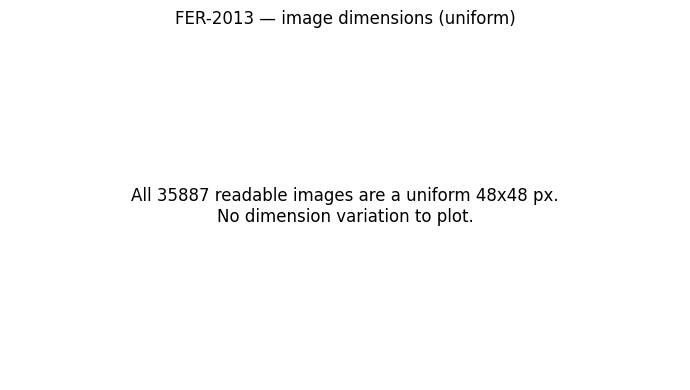

In [8]:
readable = ~is_corrupt
dim_pairs = list(zip(widths[readable].tolist(), heights[readable].tolist()))
dim_counts = pd.Series(dim_pairs).value_counts()
dim_df = dim_counts.rename_axis("(width, height)").reset_index(name="count")
print("Unique (width, height) pairs among readable files:")
print(dim_df.to_string(index=False))

uniform_dims = len(dim_df) == 1
if uniform_dims:
    only_dim = dim_df.iloc[0]["(width, height)"]
    print(f"\nAll {int(readable.sum())} readable images share a single dimension: {only_dim}")
else:
    print(f"\n{len(dim_df)} distinct dimensions found among {int(readable.sum())} readable images.")

n_resized_for_array = int(resized_flag[readable].sum())
print(f"Files whose array was resized to {TARGET_W}x{TARGET_H} for pixel-stat/hash purposes "
      f"because their original size differed: {n_resized_for_array}")

# --- plot ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
if uniform_dims:
    ax.axis("off")
    ax.text(
        0.5, 0.5,
        f"All {int(readable.sum())} readable images are a uniform {only_dim[0]}x{only_dim[1]} px.\n"
        "No dimension variation to plot.",
        ha="center", va="center", fontsize=12, wrap=True,
    )
    ax.set_title("FER-2013 — image dimensions (uniform)")
else:
    labels = [str(t) for t in dim_df["(width, height)"]]
    ax.bar(labels, dim_df["count"], color="#C44E52")
    ax.set_xlabel("(width, height)")
    ax.set_ylabel("Count")
    ax.set_title("FER-2013 — image dimension distribution")
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha("right")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "image_dimensions.png"), dpi=150, bbox_inches="tight")
plt.show()


## 5. Channels & bit depth

PIL `mode` census (e.g. `L`=8-bit grayscale, `RGB`=24-bit, `P`=8-bit palette) among readable
files, with the corresponding bits-per-channel.


In [9]:
MODE_BITS_PER_CHANNEL = {
    "1": 1, "L": 8, "P": 8, "RGB": 8, "RGBA": 8,
    "CMYK": 8, "I": 32, "F": 32, "LA": 8,
}

mode_counts = pd.Series(modes[readable]).value_counts()
mode_df = mode_counts.rename_axis("mode").reset_index(name="count")
mode_df["bits_per_channel"] = mode_df["mode"].map(MODE_BITS_PER_CHANNEL).fillna("unknown")
print("PIL mode census (readable files):")
print(mode_df.to_string(index=False))


PIL mode census (readable files):
mode  count  bits_per_channel
   L  35887                 8


## 6. Corrupt / unreadable / zero-byte files

Corruption was tested during the single pass via `PIL.Image.open(...).verify()` inside a
try/except, plus an explicit zero-byte size check. Zero corrupt files is a valid, expected result.


In [10]:
n_corrupt = int(is_corrupt.sum())
n_zero_byte = int((filesizes == 0).sum())
print(f"Corrupt/unreadable files: {n_corrupt}")
print(f"Zero-byte files: {n_zero_byte}")

if n_corrupt > 0:
    corrupt_df = pd.DataFrame({
        "path": paths[is_corrupt],
        "split": splits[is_corrupt],
        "class": classes[is_corrupt],
        "filesize_bytes": filesizes[is_corrupt],
    })
    print(corrupt_df.to_string(index=False))
    corrupt_csv_path = os.path.join(OUT_DIR, "corrupt_files.csv")
    corrupt_df.to_csv(corrupt_csv_path, index=False)
    print("Wrote:", corrupt_csv_path)
else:
    print("No corrupt/unreadable files found — skipping corrupt_files.csv.")


Corrupt/unreadable files: 0
Zero-byte files: 0
No corrupt/unreadable files found — skipping corrupt_files.csv.


## 7. Duplicate & leakage detection

The single most important check in this notebook. Three methods, each reported **separately**,
broken down by: within TRAIN, within VAL, within TEST, and **cross-group (train<->val<->test) —
this is data leakage**. Cross-group duplicates that carry *different* class labels are reported
separately again, as label noise.

- **(a) MD5** of raw file bytes — exact byte-for-byte duplicates.
- **(b) Perceptual hash (dHash)** — a 64-bit dHash implemented from scratch with numpy (resize to
  9x8, compare adjacent columns, pack to a 64-bit int). No dependency on the `imagehash` package.
- **(c) Near-duplicate scan** — Hamming distance <= 3 over the packed dHashes, computed with a
  chunked numpy XOR + an 8-bit popcount lookup table (no bit-by-bit Python loop over pairs).


In [11]:
from collections import defaultdict

group_label = np.full(N, "OTHER", dtype=object)
group_label[TRAIN_MASK] = "TRAIN"
group_label[VAL_MASK] = "VAL"
group_label[TEST_MASK] = "TEST"

# --- (b) perceptual hash: 64-bit dHash implemented from scratch -------------

def dhash_from_array(arr, hash_size=8):
    """64-bit dHash: resize to (hash_size+1, hash_size), compare adjacent columns, pack to uint64."""
    img = Image.fromarray(arr).resize((hash_size + 1, hash_size), Image.LANCZOS)
    small = np.asarray(img, dtype=np.int16)
    diff = small[:, 1:] > small[:, :-1]  # shape (hash_size, hash_size) -> hash_size**2 bits
    bits = diff.flatten()
    h = np.uint64(0)
    for b in bits:
        h = (h << np.uint64(1)) | np.uint64(1 if b else 0)
    return h

readable_idx = np.where(readable)[0]
dhashes = np.zeros(N, dtype=np.uint64)
t0 = _time.time()
for k, i in enumerate(readable_idx):
    dhashes[i] = dhash_from_array(images[i])
    if (k + 1) % 5000 == 0 or (k + 1) == len(readable_idx):
        print(f"  dHash: {k + 1}/{len(readable_idx)} readable images hashed "
              f"({_time.time() - t0:.1f}s elapsed)")
print(f"dHash computation done in {_time.time() - t0:.1f}s.")

# --- grouping helpers ---------------------------------------------------

def summarize_duplicate_groups(groups, method_name):
    total_groups = len(groups)
    total_files = sum(len(g) for g in groups)
    within_train = within_val = within_test = within_other = 0
    cross_group = 0
    cross_group_files = 0
    label_noise_groups = []
    rows_for_csv = []
    for gi, idxs in enumerate(groups):
        labels_present = {group_label[i] for i in idxs}
        classes_present = {classes[i] for i in idxs}
        if len(labels_present) > 1:
            cross_group += 1
            cross_group_files += len(idxs)
            if len(classes_present) > 1:
                label_noise_groups.append((gi, sorted(labels_present), sorted(classes_present)))
        else:
            only = next(iter(labels_present))
            if only == "TRAIN":
                within_train += 1
            elif only == "VAL":
                within_val += 1
            elif only == "TEST":
                within_test += 1
            else:
                within_other += 1
        for i in idxs:
            rows_for_csv.append({
                "group_id": f"{method_name}_{gi}",
                "method": method_name,
                "file_path": paths[i],
                "split_group": group_label[i],
                "class": classes[i],
            })

    print(f"[{method_name}] duplicate groups: {total_groups} | affected files: {total_files}")
    print(f"[{method_name}]   within TRAIN: {within_train} groups")
    print(f"[{method_name}]   within VAL:   {within_val} groups")
    print(f"[{method_name}]   within TEST:  {within_test} groups")
    if within_other:
        print(f"[{method_name}]   within OTHER: {within_other} groups")
    print(f"[{method_name}]   CROSS-GROUP (train<->val<->test) LEAKAGE: "
          f"{cross_group} groups, {cross_group_files} files")
    if cross_group > 0:
        print("!" * 70)
        print(f"!!  {method_name}: {cross_group} CROSS-GROUP DUPLICATE GROUPS — DATA LEAKAGE  !!")
        print("!" * 70)
        if label_noise_groups:
            print(f"[{method_name}] {len(label_noise_groups)} of those cross-group duplicate groups "
                  f"carry DIFFERENT class labels (label noise). Examples (split groups / classes):")
            for gi, labs, clss in label_noise_groups[:20]:
                print(f"    group {gi}: splits={labs} classes={clss}")
    else:
        print(f"[{method_name}]   No cross-group leakage detected.")

    summary = {
        "total_groups": total_groups,
        "total_files": total_files,
        "within_train_groups": within_train,
        "within_val_groups": within_val,
        "within_test_groups": within_test,
        "cross_group_groups": cross_group,
        "cross_group_files": cross_group_files,
        "cross_group_label_noise_groups": len(label_noise_groups),
    }
    return summary, rows_for_csv

all_dup_csv_rows = []

# --- (a) MD5 exact duplicates ------------------------------------------
md5_groups_map = defaultdict(list)
for i in range(N):
    h = md5_hashes[i]
    if h is not None:
        md5_groups_map[h].append(i)
md5_dup_groups = [idxs for idxs in md5_groups_map.values() if len(idxs) > 1]
print("=" * 70)
print("(a) MD5 exact-byte duplicates")
print("=" * 70)
md5_summary, md5_rows = summarize_duplicate_groups(md5_dup_groups, "md5")
all_dup_csv_rows.extend(md5_rows)

# --- (b) dHash exact duplicates -----------------------------------------
dhash_groups_map = defaultdict(list)
for i in readable_idx:
    dhash_groups_map[int(dhashes[i])].append(int(i))
dhash_dup_groups = [idxs for idxs in dhash_groups_map.values() if len(idxs) > 1]
print()
print("=" * 70)
print("(b) dHash exact-match duplicates (visually identical)")
print("=" * 70)
dhash_summary, dhash_rows = summarize_duplicate_groups(dhash_dup_groups, "dhash")
all_dup_csv_rows.extend(dhash_rows)

# --- (c) Near-duplicate scan: Hamming distance <= 3, chunked XOR + popcount --
POPCOUNT_TABLE = np.array([bin(v).count("1") for v in range(256)], dtype=np.uint8)

def hamming_distance_matrix(a_chunk, b_arr):
    """a_chunk: (c,) uint64, b_arr: (m,) uint64 -> (c, m) uint8 Hamming distances."""
    xor = np.bitwise_xor(a_chunk[:, None], b_arr[None, :])
    byte_view = xor.view(np.uint8).reshape(xor.shape[0], xor.shape[1], 8)
    return POPCOUNT_TABLE[byte_view].sum(axis=-1, dtype=np.uint8)

M = len(readable_idx)
rd = dhashes[readable_idx]
CHUNK = 1000
near_dup_pairs = []
t0 = _time.time()
for start in range(0, M, CHUNK):
    end = min(start + CHUNK, M)
    chunk = rd[start:end]
    rest = rd[start:]  # global indices >= start
    dist = hamming_distance_matrix(chunk, rest)
    c_idx = np.arange(chunk.shape[0])[:, None]
    r_idx = np.arange(rest.shape[0])[None, :]
    mask = (r_idx > c_idx) & (dist <= 3)
    ci, ri = np.nonzero(mask)
    for a, b in zip(ci.tolist(), ri.tolist()):
        real_i = int(readable_idx[start + a])
        real_j = int(readable_idx[start + b])
        near_dup_pairs.append((real_i, real_j, int(dist[a, b])))
    chunk_num = start // CHUNK
    if chunk_num % 5 == 0:
        print(f"  near-dup scan: {end}/{M} rows processed ({_time.time() - t0:.1f}s elapsed)")

elapsed = _time.time() - t0
print(f"Near-duplicate scan complete in {elapsed:.1f}s over {M} readable images "
      f"({len(near_dup_pairs)} pairs with Hamming distance <= 3).")
if elapsed > 600:
    print("WARNING: near-duplicate scan exceeded the ~10 minute budget.")

# union-find to turn pairs into groups
uf_parent = {}

def uf_find(x):
    uf_parent.setdefault(x, x)
    while uf_parent[x] != x:
        uf_parent[x] = uf_parent[uf_parent[x]]
        x = uf_parent[x]
    return x

def uf_union(x, y):
    rx, ry = uf_find(x), uf_find(y)
    if rx != ry:
        uf_parent[rx] = ry

for i, j, d in near_dup_pairs:
    uf_union(i, j)

near_dup_group_map = defaultdict(set)
for i, j, d in near_dup_pairs:
    near_dup_group_map[uf_find(i)].add(i)
    near_dup_group_map[uf_find(i)].add(j)
near_dup_groups = [sorted(v) for v in near_dup_group_map.values()]

print()
print("=" * 70)
print("(c) Near-duplicate groups (Hamming distance <= 3)")
print("=" * 70)
near_dup_summary, near_dup_rows = summarize_duplicate_groups(near_dup_groups, "near")
all_dup_csv_rows.extend(near_dup_rows)

# --- write duplicates.csv if any duplicates of any kind were found ----------
if all_dup_csv_rows:
    duplicates_df = pd.DataFrame(all_dup_csv_rows)
    duplicates_csv_path = os.path.join(OUT_DIR, "duplicates.csv")
    duplicates_df.to_csv(duplicates_csv_path, index=False)
    print()
    print("Wrote:", duplicates_csv_path)
else:
    print()
    print("No duplicates of any kind found — skipping duplicates.csv.")


  dHash: 5000/35887 readable images hashed (0.7s elapsed)
  dHash: 10000/35887 readable images hashed (1.5s elapsed)
  dHash: 15000/35887 readable images hashed (2.2s elapsed)
  dHash: 20000/35887 readable images hashed (2.9s elapsed)
  dHash: 25000/35887 readable images hashed (3.7s elapsed)
  dHash: 30000/35887 readable images hashed (4.4s elapsed)
  dHash: 35000/35887 readable images hashed (5.2s elapsed)
  dHash: 35887/35887 readable images hashed (5.3s elapsed)
dHash computation done in 5.3s.
(a) MD5 exact-byte duplicates
[md5] duplicate groups: 1516 | affected files: 3369
[md5]   within TRAIN: 936 groups
[md5]   within VAL:   16 groups
[md5]   within TEST:  7 groups
[md5]   CROSS-GROUP (train<->val<->test) LEAKAGE: 557 groups, 1323 files
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!!  md5: 557 CROSS-GROUP DUPLICATE GROUPS — DATA LEAKAGE  !!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
[md5] 26 of those cross-group duplicate gro

## 8. Pixel-intensity statistics

Mean, std, min, max, median on the 0-255 scale, computed from the in-memory `images` array
(readable files only): overall, per class, and per split (train / val / test).


Overall pixel-intensity stats (0-255 scale):
mean      129.384900
std        65.075487
min         0.000000
max       255.000000
median    134.000000

Per-class pixel-intensity stats:
   class       mean       std  min   max  median
   angry 126.534485 65.360646  0.0 255.0   130.0
 disgust 135.109487 62.629680  0.0 255.0   140.0
    fear 135.425904 65.123301  0.0 255.0   142.0
   happy 129.080529 63.352392  0.0 255.0   134.0
 neutral 123.888017 65.357700  0.0 255.0   126.0
     sad 121.035761 64.757316  0.0 255.0   124.0
surprise 146.274997 65.014769  0.0 255.0   157.0

Per-split pixel-intensity stats:
split       mean       std  min   max  median
train 129.473334 65.044782  0.0 255.0   134.0
  val 128.980326 65.024759  0.0 255.0   134.0
 test 129.082075 65.368649  0.0 255.0   134.0


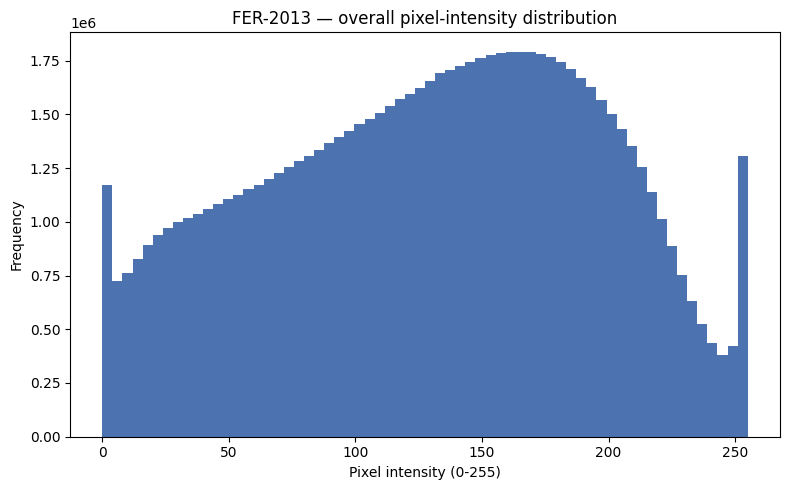

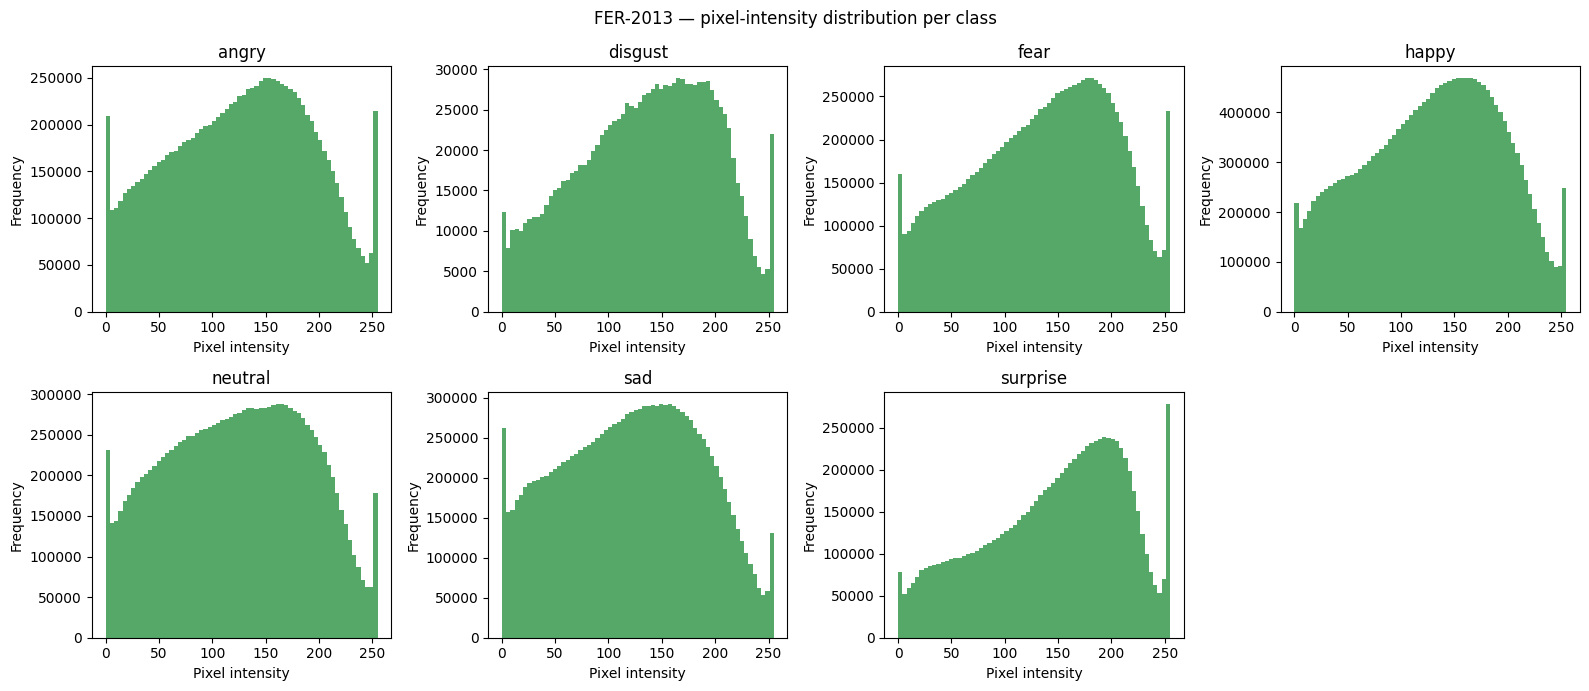

In [12]:
def pixel_stats(mask):
    pix = images[mask & readable].astype(np.float64)
    if pix.size == 0:
        return {"mean": np.nan, "std": np.nan, "min": np.nan, "max": np.nan, "median": np.nan}
    return {
        "mean": float(pix.mean()),
        "std": float(pix.std()),
        "min": float(pix.min()),
        "max": float(pix.max()),
        "median": float(np.median(pix)),
    }

overall_stats = pixel_stats(np.ones(N, dtype=bool))
print("Overall pixel-intensity stats (0-255 scale):")
print(pd.Series(overall_stats).to_string())

per_class_rows = []
for cls in CLASS_NAMES:
    stats = pixel_stats(classes == cls)
    stats["class"] = cls
    per_class_rows.append(stats)
per_class_df = pd.DataFrame(per_class_rows)[["class", "mean", "std", "min", "max", "median"]]
print()
print("Per-class pixel-intensity stats:")
print(per_class_df.to_string(index=False))

per_split_rows = []
for name, mask in (("train", TRAIN_MASK), ("val", VAL_MASK), ("test", TEST_MASK)):
    stats = pixel_stats(mask)
    stats["split"] = name
    per_split_rows.append(stats)
per_split_df = pd.DataFrame(per_split_rows)[["split", "mean", "std", "min", "max", "median"]]
print()
print("Per-split pixel-intensity stats:")
print(per_split_df.to_string(index=False))

# --- plots ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(images[readable].reshape(-1), bins=64, range=(0, 255), color="#4C72B0")
ax.set_xlabel("Pixel intensity (0-255)")
ax.set_ylabel("Frequency")
ax.set_title("FER-2013 — overall pixel-intensity distribution")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "pixel_intensity_overall.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, cls in zip(axes, CLASS_NAMES):
    pix = images[(classes == cls) & readable].reshape(-1)
    ax.hist(pix, bins=64, range=(0, 255), color="#55A868")
    ax.set_title(cls)
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Frequency")
for ax in axes[len(CLASS_NAMES):]:
    ax.axis("off")
fig.suptitle("FER-2013 — pixel-intensity distribution per class")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "pixel_intensity_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()


## 9. Visual inspection grid

One figure: a row of ~10 random (seeded) train images per class, labelled.


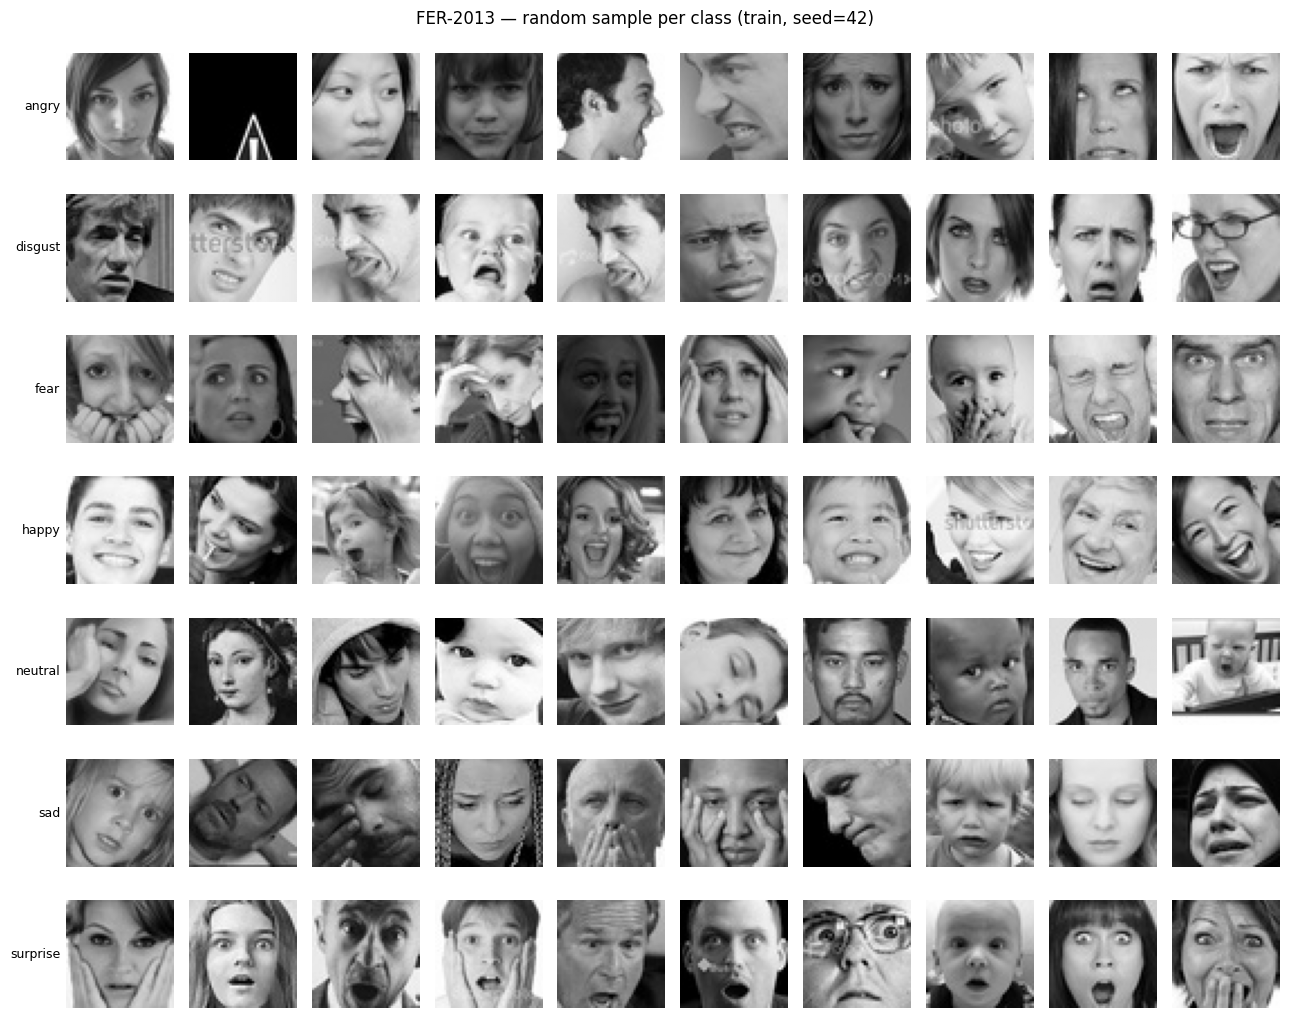

In [13]:
rng = np.random.default_rng(RUN["random_seed"])
N_SAMPLES = 10

fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLES, figsize=(N_SAMPLES * 1.3, len(CLASS_NAMES) * 1.5))
for row, cls in enumerate(CLASS_NAMES):
    cls_idx = np.where((classes == cls) & TRAIN_MASK & readable)[0]
    chosen = rng.choice(cls_idx, size=min(N_SAMPLES, len(cls_idx)), replace=False)
    for col in range(N_SAMPLES):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(chosen):
            ax.imshow(images[chosen[col]], cmap="gray", vmin=0, vmax=255)
        if col == 0:
            ax.set_ylabel(cls, rotation=0, ha="right", va="center", fontsize=9)
            ax.axis("on")
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
fig.suptitle("FER-2013 — random sample per class (train, seed=42)")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "sample_grid_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()


## 10. Quality anomalies (candidates for human review)

Programmatic flags only: near-constant images (very low std), fully-black/fully-white images, and
extreme-brightness outliers. These are **candidates for a human to judge** — this notebook cannot
determine whether an image is or is not a face, so it never claims that.


Near-constant images (per-image std < 5.0): 14
Fully-black images (mean <= 1.0): 12
Fully-white images (mean >= 254.0): 0
Extreme-brightness outliers (|z| >= 3.0): 67
Total distinct flagged images (any criterion): 68


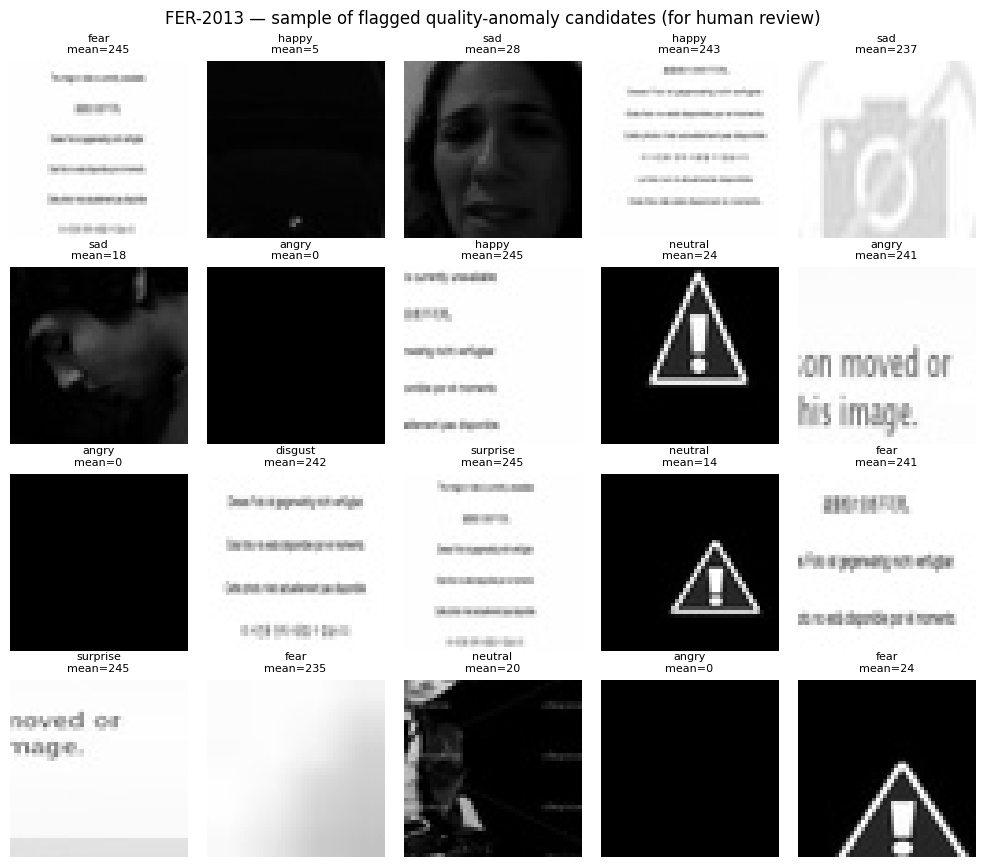

In [14]:
LOW_STD_THRESHOLD = 5.0       # near-constant image
BRIGHTNESS_Z_THRESHOLD = 3.0  # extreme-brightness outlier, in std-devs from the per-file mean's own distribution

readable_idx_arr = np.where(readable)[0]
per_image_mean = images[readable_idx_arr].reshape(len(readable_idx_arr), -1).astype(np.float64).mean(axis=1)
per_image_std = images[readable_idx_arr].reshape(len(readable_idx_arr), -1).astype(np.float64).std(axis=1)

near_constant_mask = per_image_std < LOW_STD_THRESHOLD
fully_black_mask = per_image_mean <= 1.0
fully_white_mask = per_image_mean >= 254.0

overall_mean_of_means = per_image_mean.mean()
overall_std_of_means = per_image_mean.std()
brightness_z = (per_image_mean - overall_mean_of_means) / max(overall_std_of_means, 1e-9)
brightness_outlier_mask = np.abs(brightness_z) >= BRIGHTNESS_Z_THRESHOLD

print(f"Near-constant images (per-image std < {LOW_STD_THRESHOLD}): {int(near_constant_mask.sum())}")
print(f"Fully-black images (mean <= 1.0): {int(fully_black_mask.sum())}")
print(f"Fully-white images (mean >= 254.0): {int(fully_white_mask.sum())}")
print(f"Extreme-brightness outliers (|z| >= {BRIGHTNESS_Z_THRESHOLD}): {int(brightness_outlier_mask.sum())}")

flagged_any_mask = near_constant_mask | fully_black_mask | fully_white_mask | brightness_outlier_mask
flagged_indices = readable_idx_arr[flagged_any_mask]
print(f"Total distinct flagged images (any criterion): {len(flagged_indices)}")

if len(flagged_indices) > 0:
    n_show = min(20, len(flagged_indices))
    show_idx = rng.choice(flagged_indices, size=n_show, replace=False)
    n_cols = 5
    n_rows = int(np.ceil(n_show / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.2))
    axes = np.atleast_1d(axes).flatten()
    for ax, idx in zip(axes, show_idx):
        ax.imshow(images[idx], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"{classes[idx]}\nmean={images[idx].mean():.0f}", fontsize=8)
        ax.axis("off")
    for ax in axes[n_show:]:
        ax.axis("off")
    fig.suptitle("FER-2013 — sample of flagged quality-anomaly candidates (for human review)")
    plt.tight_layout()
    plt.show()
else:
    print("No quality-anomaly candidates flagged — skipping sample grid.")


## 11. Class names

The seven directory names exactly as they appear on disk, sorted, with an assertion that the
train and test class sets are identical (already checked once during the single pass; re-asserted
here for visibility at the end of the analysis).


In [15]:
print("Class names (sorted, as they appear on disk):")
for cls in CLASS_NAMES:
    print(" -", cls)

assert set(CLASS_NAMES_TRAIN) == set(CLASS_NAMES_TEST), "train/test class sets differ"
print()
print(f"train and test class sets are identical: {len(CLASS_NAMES)} classes.")


Class names (sorted, as they appear on disk):
 - angry
 - disgust
 - fear
 - happy
 - neutral
 - sad
 - surprise

train and test class sets are identical: 7 classes.


## 12. Artifacts

Writes, into `OUT_DIR`:

- `dataset_summary.json` — every measured figure from the analyses above, in one machine-readable
  file.
- `verified_dataset_facts.md` — the same facts as a markdown section, generated **at runtime** from
  the measured values. This is handed to the project owner to paste into `ml/fer/README.md`; it is
  **not** written there by this notebook.
- The run-metadata JSON via `save_run()`, with `RUN["metrics"]` and `RUN["notes"]` populated from
  the measured results.


In [16]:
def df_to_md_table(df):
    """Minimal DataFrame -> GitHub-flavoured markdown table, no extra dependency (no tabulate)."""
    cols = list(df.columns)
    header = "| " + " | ".join(cols) + " |"
    sep = "| " + " | ".join("---" for _ in cols) + " |"
    body_rows = []
    for _, row in df.iterrows():
        body_rows.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join([header, sep] + body_rows)

dataset_summary = {
    "dataset": "FER-2013",
    "dataset_root": DATA_ROOT,
    "class_names": CLASS_NAMES,
    "totals": {
        "overall_files": int(N),
        "train_files": int(TRAIN_MASK.sum()),
        "val_files": int(VAL_MASK.sum()),
        "test_files": int(TEST_MASK.sum()),
    },
    "per_class_counts": {
        "train": train_dist.set_index("class")["count"].astype(int).to_dict(),
        "val": val_dist.set_index("class")["count"].astype(int).to_dict(),
        "test": test_only_dist.set_index("class")["count"].astype(int).to_dict(),
    },
    "imbalance_ratio": {
        "train_max_min": float(train_ratio),
        "test_max_min": float(test_ratio),
    },
    "prefix_census": {
        "cross_tab": cross_tab.to_dict(orient="index"),
        "checks": checks,
        "all_checks_passed": bool(all_passed),
    },
    "dimensions": {
        "unique_dimensions": dim_df.astype(str).to_dict(orient="records"),
        "uniform": bool(uniform_dims),
    },
    "channels_modes": mode_df.astype(str).to_dict(orient="records"),
    "corrupt_files": {
        "count": int(n_corrupt),
        "zero_byte_count": int(n_zero_byte),
    },
    "duplicates": {
        "md5": md5_summary,
        "dhash": dhash_summary,
        "near_duplicate": near_dup_summary,
    },
    "cross_group_leakage": {
        "md5": md5_summary["cross_group_files"],
        "dhash": dhash_summary["cross_group_files"],
        "near_duplicate": near_dup_summary["cross_group_files"],
    },
    "pixel_stats": {
        "overall": overall_stats,
        "per_class": per_class_df.set_index("class").to_dict(orient="index"),
        "per_split": per_split_df.set_index("split").to_dict(orient="index"),
    },
    "quality_anomalies": {
        "near_constant": int(near_constant_mask.sum()),
        "fully_black": int(fully_black_mask.sum()),
        "fully_white": int(fully_white_mask.sum()),
        "brightness_outliers": int(brightness_outlier_mask.sum()),
    },
}

summary_path = os.path.join(OUT_DIR, "dataset_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(dataset_summary, f, indent=2, default=str)
print("saved:", summary_path)

# --- verified_dataset_facts.md, generated from measured values --------------
lines = []
lines.append("## Verified dataset facts\n")
lines.append(f"_Generated at runtime by `01_dataset_exploration.ipynb`, run `{RUN['run_id']}`._\n")
lines.append("")
lines.append(f"- Dataset root resolved to: `{DATA_ROOT}`")
lines.append(f"- Total files: {N} (train: {int(TRAIN_MASK.sum())}, "
             f"val/PublicTest: {int(VAL_MASK.sum())}, test/PrivateTest: {int(TEST_MASK.sum())})")
lines.append(f"- Classes ({len(CLASS_NAMES)}): {', '.join(CLASS_NAMES)}")
lines.append(f"- Train max:min class imbalance ratio: {train_ratio:.2f}")
lines.append(f"- Test max:min class imbalance ratio: {test_ratio:.2f}")
lines.append(f"- Prefix census: {'ALL PASSED' if all_passed else 'FAILED — see notebook output'}")
lines.append(f"- Image dimensions: "
             f"{'uniform ' + str(only_dim) if uniform_dims else str(len(dim_df)) + ' distinct sizes found'}")
lines.append(f"- Corrupt/unreadable files: {n_corrupt} (zero-byte: {n_zero_byte})")
lines.append(f"- MD5 exact-duplicate groups: {md5_summary['total_groups']} "
             f"(cross-group leakage: {md5_summary['cross_group_groups']} groups, "
             f"{md5_summary['cross_group_files']} files)")
lines.append(f"- dHash exact-duplicate groups: {dhash_summary['total_groups']} "
             f"(cross-group leakage: {dhash_summary['cross_group_groups']} groups, "
             f"{dhash_summary['cross_group_files']} files)")
lines.append(f"- Near-duplicate groups (Hamming<=3): {near_dup_summary['total_groups']} "
             f"(cross-group leakage: {near_dup_summary['cross_group_groups']} groups, "
             f"{near_dup_summary['cross_group_files']} files)")
lines.append(f"- Overall pixel intensity: mean={overall_stats['mean']:.2f}, "
             f"std={overall_stats['std']:.2f}, min={overall_stats['min']:.0f}, "
             f"max={overall_stats['max']:.0f}, median={overall_stats['median']:.1f}")
lines.append(f"- Quality-anomaly candidates flagged: near-constant={int(near_constant_mask.sum())}, "
             f"fully-black={int(fully_black_mask.sum())}, fully-white={int(fully_white_mask.sum())}, "
             f"brightness-outliers={int(brightness_outlier_mask.sum())}")
lines.append("")
lines.append("### Per-split class distribution")
lines.append("")
lines.append("Train:\n\n" + df_to_md_table(train_dist))
lines.append("\nVal (PublicTest):\n\n" + df_to_md_table(val_dist))
lines.append("\nTest (PrivateTest):\n\n" + df_to_md_table(test_only_dist))

facts_md = "\n".join(str(x) for x in lines) + "\n"
facts_path = os.path.join(OUT_DIR, "verified_dataset_facts.md")
with open(facts_path, "w", encoding="utf-8") as f:
    f.write(facts_md)
print("saved:", facts_path)
print()
print("--- verified_dataset_facts.md content (paste into ml/fer/README.md manually) ---")
print(facts_md)

# --- populate RUN metadata and save it (final analysis cell) ----------------
RUN["metrics"] = {
    "total_files": int(N),
    "train_files": int(TRAIN_MASK.sum()),
    "val_files": int(VAL_MASK.sum()),
    "test_files": int(TEST_MASK.sum()),
    "train_imbalance_ratio": float(train_ratio),
    "test_imbalance_ratio": float(test_ratio),
    "corrupt_files": int(n_corrupt),
    "md5_duplicate_groups": md5_summary["total_groups"],
    "dhash_duplicate_groups": dhash_summary["total_groups"],
    "near_duplicate_groups": near_dup_summary["total_groups"],
    "cross_group_leakage_files_md5": md5_summary["cross_group_files"],
    "cross_group_leakage_files_dhash": dhash_summary["cross_group_files"],
    "cross_group_leakage_files_near": near_dup_summary["cross_group_files"],
}
RUN["notes"] = (
    f"Prefix census: {'ALL CHECKS PASSED' if all_passed else 'FAILED — see cell output for detail'}. "
    f"Checks: {checks}."
)

save_run(RUN)


saved: /content/maternalink_fer/outputs/dataset_summary.json
saved: /content/maternalink_fer/outputs/verified_dataset_facts.md

--- verified_dataset_facts.md content (paste into ml/fer/README.md manually) ---
## Verified dataset facts

_Generated at runtime by `01_dataset_exploration.ipynb`, run `run_20260818_220610`._


- Dataset root resolved to: `/content/fer_data`
- Total files: 35887 (train: 28709, val/PublicTest: 3589, test/PrivateTest: 3589)
- Classes (7): angry, disgust, fear, happy, neutral, sad, surprise
- Train max:min class imbalance ratio: 16.55
- Test max:min class imbalance ratio: 15.98
- Prefix census: ALL PASSED
- Image dimensions: uniform (48, 48)
- Corrupt/unreadable files: 0 (zero-byte: 0)
- MD5 exact-duplicate groups: 1516 (cross-group leakage: 557 groups, 1323 files)
- dHash exact-duplicate groups: 1581 (cross-group leakage: 588 groups, 1422 files)
- Near-duplicate groups (Hamming<=3): 2051 (cross-group leakage: 807 groups, 2311 files)
- Overall pixel intensity: m

'/content/maternalink_fer/outputs/run_20260818_220610.json'

## 13. Download artifacts (Colab only)

On Colab, `OUT_DIR`/`PLOT_DIR` live under `/content`, which is not the repo. This zips everything
produced above and triggers a browser download. Locally, this cell is a no-op — the files are
already sitting in `../outputs` and `../plots`.


In [17]:
if IN_COLAB:
    import shutil
    from google.colab import files as colab_files

    archive_base = "/content/notebook01_artifacts"
    archive_path = shutil.make_archive(archive_base, "zip", "/content/maternalink_fer")
    print("Created archive:", archive_path)
    print()
    print("After downloading, unzip it locally and place:")
    print("  outputs/*  ->  ml/fer/outputs/")
    print("  plots/*    ->  ml/fer/plots/")
    print("into the repo (this notebook cannot write to the repo from Colab).")
    colab_files.download(archive_path)
else:
    print("Not running on Colab — artifacts were already written directly to "
          f"{OUT_DIR} and {PLOT_DIR}. Nothing to zip/download.")


Created archive: /content/notebook01_artifacts.zip

After downloading, unzip it locally and place:
  outputs/*  ->  ml/fer/outputs/
  plots/*    ->  ml/fer/plots/
into the repo (this notebook cannot write to the repo from Colab).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>